# 2026-06-17 Initial Check: rMZR with Infall-Stage Colouring

Contains the standard
rMZR/OH-SFR/BPT/Spearman checks on current `further` products, plus new cells
where plots are colour-coded by **infall stage** (from `mauve_master_wiki_newclass.fits`):
- **Blue** = Stage 1 (pre-peak)
- **Green** = Stage 2 (close-to-peak)
- **Red** = Stage 3 (post-peak)

## Setup copied from source notebook

These cells use only galaxies/products discovered below the current `further` run directory.
Infall-stage cells additionally load the `class` column from `mauve_master_wiki_newclass.fits`
(1 = pre-peak, 2 = close-to-peak, 3 = post-peak) and assign BGR colours accordingly.

In [1]:
# Combined further-project initial checks using current further products only.
# The active science sample is: all currently science-ready `further` products.
# Downstream cells keep using the same helper names as the 20260525 notebook.

from __future__ import annotations

import math
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

KEY_LINES = [
    "HB4861",
    "OIII5006",
    "HA6562",
    "NII6583",
    "SII6716",
    "SII6730",
    "SIII6312",
    "OII7318",
    "OII7319",
    "OII7329",
    "OII7330",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active PRODUCT paths use current `further` products only.")
print("Active save paths are intentionally commented out in this notebook.")

Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active PRODUCT paths use current `further` products only.
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 32
Science-ready current further galaxies: 32
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


## Fixed galaxy colors

The mapping below is copied from `20260530_MAUVE_galaxy_colors.md` and the palette-test notebook convention, not loaded from `MAUVE_galaxy_colors.dat`.

In [4]:
# Fixed MAUVE galaxy-color convention copied from:
# - 20260530_MAUVE_galaxy_colors.md
# - 20260529_test_galaxy_color_palette.ipynb
#
# Per request, this notebook does not load MAUVE_galaxy_colors.dat.
from matplotlib.colors import ListedColormap

FIXED_GALAXY_PALETTE_NAME = "MAUVE_GALAXY_GLASBEY_PACKAGE_40"
FIXED_GALAXY_ORDER = [
    'IC3392',
    'NGC4064',
    'NGC4189',
    'NGC4192',
    'NGC4216',
    'NGC4222',
    'NGC4254',
    'NGC4293',
    'NGC4294',
    'NGC4298',
    'NGC4302',
    'NGC4321',
    'NGC4330',
    'NGC4351',
    'NGC4380',
    'NGC4383',
    'NGC4388',
    'NGC4394',
    'NGC4396',
    'NGC4402',
    'NGC4405',
    'NGC4419',
    'NGC4424',
    'NGC4450',
    'NGC4457',
    'NGC4501',
    'NGC4522',
    'NGC4535',
    'NGC4548',
    'NGC4567',
    'NGC4568',
    'NGC4569',
    'NGC4579',
    'NGC4580',
    'NGC4606',
    'NGC4607',
    'NGC4654',
    'NGC4689',
    'NGC4694',
    'NGC4698',
]
TOTAL_ASSEMBLED_COLOR = "black"
FIXED_GALAXY_COLORS = {
    'IC3392': '#d21820',
    'NGC4064': '#6175ff',
    'NGC4189': '#008a00',
    'NGC4192': '#ff79fb',
    'NGC4216': '#aafb00',
    'NGC4222': '#713971',
    'NGC4254': '#00dbc2',
    'NGC4293': '#ff9e04',
    'NGC4294': '#35595d',
    'NGC4298': '#6d4904',
    'NGC4302': '#aa657d',
    'NGC4321': '#a2aaff',
    'NGC4330': '#92aa65',
    'NGC4351': '#a241ff',
    'NGC4380': '#00ff96',
    'NGC4383': '#c60079',
    'NGC4388': '#ffaeca',
    'NGC4394': '#697996',
    'NGC4396': '#a67d00',
    'NGC4402': '#697955',
    'NGC4405': '#ffe392',
    'NGC4419': '#ff6182',
    'NGC4424': '#863135',
    'NGC4450': '#a6e7ff',
    'NGC4457': '#1cc600',
    'NGC4501': '#35518e',
    'NGC4522': '#ff5d00',
    'NGC4535': '#a682be',
    'NGC4548': '#04a6ef',
    'NGC4567': '#04aa75',
    'NGC4568': '#aa592d',
    'NGC4569': '#cac200',
    'NGC4579': '#08612d',
    'NGC4580': '#dfd2fb',
    'NGC4606': '#ca9679',
    'NGC4607': '#d200df',
    'NGC4654': '#8eaaba',
    'NGC4689': '#bae3c2',
    'NGC4694': '#6500ff',
    'NGC4698': '#008a8a',
    'NGC4567_8': '#04aa75',
}
FIXED_GALAXY_CMAP = ListedColormap(
    [FIXED_GALAXY_COLORS[g] for g in FIXED_GALAXY_ORDER],
    name=FIXED_GALAXY_PALETTE_NAME,
)

def galaxy_color(galaxy: str) -> str:
    if galaxy in FIXED_GALAXY_COLORS:
        return FIXED_GALAXY_COLORS[galaxy]
    print(f"Warning: {galaxy} is not in the fixed MAUVE galaxy palette; using gray fallback.")
    return "#777777"

def ordered_galaxies_by_fixed_palette(galaxies):
    requested = list(galaxies)
    remaining = set(requested)
    ordered = []
    for galaxy in FIXED_GALAXY_ORDER:
        if galaxy in remaining:
            ordered.append(galaxy)
            remaining.remove(galaxy)
        if galaxy == "NGC4567" and "NGC4567_8" in remaining:
            ordered.append("NGC4567_8")
            remaining.remove("NGC4567_8")
    ordered.extend(sorted(remaining))
    return ordered

def galaxy_legend_handles(galaxies, marker="o", markersize=6):
    from matplotlib.lines import Line2D
    return [
        Line2D(
            [0], [0], marker=marker, color="none", linestyle="None",
            markerfacecolor=galaxy_color(galaxy), markeredgecolor="none",
            markersize=markersize, label=galaxy,
        )
        for galaxy in galaxies
    ]

print(f"Loaded fixed {FIXED_GALAXY_PALETTE_NAME} mapping for {len(FIXED_GALAXY_ORDER)} component galaxies.")
print(f"NGC4567_8 alias color: {FIXED_GALAXY_COLORS['NGC4567_8']}; total/pooled color: {TOTAL_ASSEMBLED_COLOR}")


Loaded fixed MAUVE_GALAXY_GLASBEY_PACKAGE_40 mapping for 40 component galaxies.
NGC4567_8 alias color: #04aa75; total/pooled color: black


In [5]:
# Reusable helpers for fixed-galaxy-color plot variants.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage
import scipy.stats as stats

EW_FILE_SUFFIX = "_proxy_EW_maps.fits"
EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
EXCLUDED_GALAXIES = {"NGC4383"}
COMMON_YLIM_M13 = (8.2, 8.9)
COMMON_YLIM_M13_C20 = (8.2, 9.1)
XRANGE_RMZR = (6.0, 10.0)
XRANGE_ZGAS = (-5.0, 0.5)


def require_hdu_data(hdul, hdu_name, filename):
    if hdu_name not in hdul:
        raise KeyError(f"Missing HDU {hdu_name!r} in {filename}")
    return np.asarray(hdul[hdu_name].data, dtype=float)


def intrinsic_ha_sigma_from_gas_hdul(h_gas, galaxy):
    ha_sigma_obs = require_hdu_data(h_gas, "HA6562_SIGMA", further_gas_path(galaxy))
    ha_sigma_corr = require_hdu_data(h_gas, "HA6562_SIGMA_CORR", further_gas_path(galaxy))
    ha_sigma_corr = align_map_to_shape(ha_sigma_corr, ha_sigma_obs.shape, label=f"{galaxy} HA6562_SIGMA_CORR")
    sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
    ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return ha_sigma


def load_common_maps_for_galaxy(galaxy, *, include_c20=False, require_sigma_mask=True):
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy, EW_FILE_SUFFIX)

    with fits.open(spatial_path) as h_spatial:
        log_sigma_m = require_hdu_data(h_spatial, "LOGMASS_SURFACE_DENSITY", spatial_path)

    with fits.open(gas_path) as h_gas:
        log_sigma_sfr = require_hdu_data(h_gas, "LOGSFR_SURFACE_DENSITY_HII", gas_path)
        oh_m13 = require_hdu_data(h_gas, "O_H_O3N2_M13_HII", gas_path)
        oh_c20 = require_hdu_data(h_gas, "O_H_O3N2_C20_HII", gas_path) if include_c20 else None
        ha_sigma = intrinsic_ha_sigma_from_gas_hdul(h_gas, galaxy) if require_sigma_mask else None

    with fits.open(ew_path) as h_ew:
        ew_ha = require_hdu_data(h_ew, EW_HDU, ew_path)
    ew_ha = align_map_to_shape(ew_ha, log_sigma_sfr.shape, label=f"{galaxy} {EW_HDU}")

    out = {
        "logSigmaM": log_sigma_m,
        "logSigmaSFR": log_sigma_sfr,
        "oh_m13": oh_m13,
        "oh_c20": oh_c20,
        "ew_ha": ew_ha,
        "ha_sigma": ha_sigma,
    }
    return out


def calculate_binned_stats_for_color(x_data, y_data, bin_width=0.4, min_pixels=20):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]
    if x_data.size == 0:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    medians, stds, counts, centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        x_in_bin = x_data[in_bin]
        if np.sum(np.isfinite(y_in_bin)) >= min_pixels:
            centers.append(np.nanmedian(x_in_bin))
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(np.sum(np.isfinite(y_in_bin)))
            valid_bin_indices.append(i)
    return (np.asarray(centers), np.asarray(medians), np.asarray(stds), np.asarray(counts), np.asarray(valid_bin_indices))


def mzr_model_for_color(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def compute_density_mask_for_color(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    empty_mask = np.zeros_like(x_vals, dtype=bool)
    if not np.any(mask_finite):
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    if np.sum(H) <= 0:
        return (empty_mask, None, None) if return_contour else empty_mask
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    if H_cumsum[-1] <= 0:
        return (empty_mask, None, None) if return_contour else empty_mask
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_idx = min(level_idx, len(H_flat) - 1)
    level_95 = H_flat[level_idx]
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


def density_contour_level_for_color(H_smooth, enclosed_fraction=0.95):
    positive = np.asarray(H_smooth, dtype=float)
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if positive.size < 4:
        return None
    ordered = np.sort(positive.ravel())[::-1]
    cumulative = np.cumsum(ordered)
    if cumulative[-1] <= 0:
        return None
    idx = int(np.searchsorted(cumulative, enclosed_fraction * cumulative[-1]))
    idx = min(idx, ordered.size - 1)
    level = float(ordered[idx])
    if not (positive.min() < level < positive.max()):
        level = float(0.5 * (positive.min() + positive.max()))
    return level


def plot_closed_95_contour_for_color(
    ax,
    x_vals,
    y_vals,
    *,
    x_range,
    y_range,
    color,
    label=None,
    nbins=90,
    sigma=1.5,
    min_points=50,
    linewidth=1.8,
    alpha=0.9,
    linestyle="-",
):
    """Draw one closed 95% density contour for a galaxy point distribution."""
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if np.sum(finite) < min_points:
        return None
    x = x_vals[finite]
    y = y_vals[finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    if np.sum(H) <= 0:
        return None
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    level = density_contour_level_for_color(H_smooth, enclosed_fraction=0.95)
    if level is None:
        return None
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(x_centers, y_centers)
    contour = ax.contour(
        X,
        Y,
        H_smooth.T,
        levels=[level],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
        alpha=alpha,
    )
    if label is not None:
        contour.collections[0].set_label(label)
    return contour


def galaxy_contour_legend_handles(galaxies, linewidth=2.0):
    from matplotlib.lines import Line2D
    return [Line2D([0], [0], color=galaxy_color(galaxy), lw=linewidth, label=galaxy) for galaxy in galaxies]


def plot_literature_mzr_fits_for_color(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sánchez+13 (CALIFA, z~0.016)", "--", "cyan"))
    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "BB+16 (MaNGA, z~0.045)", "--", "green"))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, "EF+19 (MAD, z<0.013)", "--", "blue"))
    handles = []
    for x, y, label, linestyle, color in plot_data:
        line, = ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)
        handles.append(line)
    return handles


def plot_literature_baker_for_color(ax, show_legend=True):
    x_baker = np.linspace(6.1, 8.5, 200)
    logSigmaSFR_ref = -2.0
    Z0_B = 8.75
    gamma_B = 0.14
    phi_B = 2.73
    m0_B = 8.58
    m1_B = 0.50
    logM0_B = m0_B + m1_B * logSigmaSFR_ref
    M0_B = 10.0 ** logM0_B
    Sigma_star_B = 10.0 ** x_baker
    y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(1.0 + (Sigma_star_B / M0_B) ** (-phi_B))
    line, = ax.plot(x_baker, y_baker23, label="Baker+23 (MaNGA, z~0.03)" if show_legend else None, linewidth=2, linestyle="--", color="brown")
    return [line]


def safe_fit_and_plot_for_color(ax, x, y, linestyle, label):
    finite = np.isfinite(x) & np.isfinite(y)
    x_fit_data = np.asarray(x)[finite]
    y_fit_data = np.asarray(y)[finite]
    if len(x_fit_data) < 10:
        print(f"{label}: not enough points for fitting.")
        return None, None, None, None
    p0 = [8.5, 0.0002, 12.5]
    bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
    try:
        popt, pcov = curve_fit(mzr_model_for_color, x_fit_data, y_fit_data, p0=p0, bounds=bounds, maxfev=5000)
        x_model = np.linspace(np.nanmin(x_fit_data), np.nanmax(x_fit_data), 150)
        y_model = mzr_model_for_color(x_model, *popt)
        line, = ax.plot(x_model, y_model, linestyle, linewidth=2, color=TOTAL_ASSEMBLED_COLOR, label=label)
        perr = np.sqrt(np.diag(pcov))
        print(f"{label}: a={popt[0]:.3f} ± {perr[0]:.3f}, b={popt[1]:.5f} ± {perr[1]:.5f}, c={popt[2]:.3f} ± {perr[2]:.3f}")
        return line, popt, pcov, (x_model, y_model)
    except Exception as exc:
        print(f"{label} fit failed: {exc}")
        return None, None, None, None


def plot_global_median_for_color(ax, x, y, *, x_range, y_range, label, bin_width=0.4, min_pixels=20):
    mask_95 = compute_density_mask_for_color(x, y, x_range, y_range)
    centers, medians, stds, counts, valid_indices = calculate_binned_stats_for_color(x[mask_95], y[mask_95], bin_width=bin_width, min_pixels=min_pixels)
    if len(centers) >= 3:
        yerr = stds / np.sqrt(counts)
        handle = ax.errorbar(centers, medians, yerr=yerr, color=TOTAL_ASSEMBLED_COLOR, marker="o", markersize=6, linewidth=2.0, capsize=4, capthick=1.5, alpha=0.95, label=label)
        return handle
    return None


def calculate_binned_stats_unique_for_color(x_data, y_data, *, bin_width=0.2, min_unique=20):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]
    if x_data.size == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    valid_centers, medians, stds, counts = [], [], [], []
    for center, bin_start, bin_end in zip(centers, bin_edges[:-1], bin_edges[1:]):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_bin = y_data[in_bin]
        if len(np.unique(y_bin[np.isfinite(y_bin)])) >= min_unique:
            valid_centers.append(center)
            medians.append(np.nanmedian(y_bin))
            stds.append(np.nanstd(y_bin))
            counts.append(np.sum(np.isfinite(y_bin)))
    return np.asarray(valid_centers), np.asarray(medians), np.asarray(stds), np.asarray(counts)


def spearman_rho_by_primary_bin_for_color(
    primary_axis,
    companion_axis,
    oh_axis,
    *,
    n_bins=6,
    percentile_limits=(2.5, 97.5),
    trend_bin_width=0.2,
    min_unique=20,
):
    """Cell-17 style Spearman rho of delta [O/H] vs delta companion in primary-axis bins."""
    primary_axis = np.asarray(primary_axis, dtype=float)
    companion_axis = np.asarray(companion_axis, dtype=float)
    oh_axis = np.asarray(oh_axis, dtype=float)
    valid_all = np.isfinite(primary_axis) & np.isfinite(companion_axis) & np.isfinite(oh_axis)
    if np.sum(valid_all) < 10:
        return np.array([]), np.array([]), np.array([]), np.array([])

    primary_min = np.nanpercentile(primary_axis[valid_all], percentile_limits[0])
    primary_max = np.nanpercentile(primary_axis[valid_all], percentile_limits[1])
    if not np.isfinite(primary_min) or not np.isfinite(primary_max) or primary_min == primary_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    edges = np.linspace(primary_min, primary_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rho_centers, rho_values, p_values, counts = [], [], [], []

    for i, center in enumerate(centers):
        if i == n_bins - 1:
            bin_mask = valid_all & (primary_axis >= edges[i]) & (primary_axis <= edges[i + 1])
        else:
            bin_mask = valid_all & (primary_axis >= edges[i]) & (primary_axis < edges[i + 1])
        n_pixels = int(np.sum(bin_mask))
        if n_pixels <= 2:
            continue

        companion_bin = companion_axis[bin_mask]
        oh_bin = oh_axis[bin_mask]
        companion_offset = companion_bin - np.nanmean(companion_bin)
        oh_offset = oh_bin - np.nanmean(oh_bin)
        valid_corr = np.isfinite(companion_offset) & np.isfinite(oh_offset)
        if np.sum(valid_corr) <= 2:
            continue

        clip_mask = np.zeros_like(valid_corr, dtype=bool)
        companion_data = companion_offset[valid_corr]
        oh_data = oh_offset[valid_corr]
        companion_unique = np.unique(companion_data)
        oh_unique = np.unique(oh_data)
        if companion_unique.size <= 1 or oh_unique.size <= 1:
            continue

        x_mean, x_std = np.mean(companion_unique), np.std(companion_unique)
        y_mean, y_std = np.mean(oh_unique), np.std(oh_unique)
        within_3sigma = (
            (companion_data >= x_mean - 3 * x_std)
            & (companion_data <= x_mean + 3 * x_std)
            & (oh_data >= y_mean - 3 * y_std)
            & (oh_data <= y_mean + 3 * y_std)
        )
        clip_mask[valid_corr] = within_3sigma

        trend_centers, _, _, _ = calculate_binned_stats_unique_for_color(
            companion_offset[clip_mask],
            oh_offset[clip_mask],
            bin_width=trend_bin_width,
            min_unique=min_unique,
        )
        has_trend = trend_centers.size >= 3
        corr_mask = clip_mask & valid_corr
        if not has_trend or np.sum(corr_mask) <= 2:
            continue

        rho, p_value = stats.spearmanr(companion_offset[corr_mask], oh_offset[corr_mask])
        if np.isfinite(rho):
            rho_centers.append(center)
            rho_values.append(rho)
            p_values.append(p_value)
            counts.append(n_pixels)

    return np.asarray(rho_centers), np.asarray(rho_values), np.asarray(p_values), np.asarray(counts)


def plot_per_galaxy_spearman_by_mass_for_color(
    ax,
    per_galaxy,
    galaxies,
    *,
    linewidth=1.6,
    alpha=0.85,
    min_bins_to_plot=3,
):
    plotted = []
    for gal in galaxies:
        if gal not in per_galaxy:
            continue
        data = per_galaxy[gal]
        centers, rho_values, p_values, counts = spearman_rho_by_primary_bin_for_color(
            data["logSigmaM"],
            data["logSigmaSFR"],
            data["oh_m13"],
        )
        if rho_values.size < min_bins_to_plot:
            print(f"  {gal}: Spearman bins plotted=0 (valid bins={rho_values.size})")
            continue
        order = np.argsort(centers)
        ax.plot(
            centers[order],
            rho_values[order],
            color=galaxy_color(gal),
            linewidth=linewidth,
            alpha=alpha,
            label=gal,
        )
        plotted.append(gal)
        print(f"  {gal}: Spearman bins plotted={rho_values.size}")

    ax.axhline(0.0, color="0.45", linestyle="--", linewidth=1.0, alpha=0.65)
    ax.set_xlim(*XRANGE_RMZR)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_\mathrm{SFR}$]', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.text(
        0.02,
        0.98,
        r"Per-galaxy Spearman $\rho$ in $\Sigma_*$ bins",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
    )
    return plotted


  IC3392: 21521 valid spaxels (flux+SFR+EW mask)
  NGC4064: 22698 valid spaxels (flux+SFR+EW mask)
  NGC4189: 141289 valid spaxels (flux+SFR+EW mask)
  NGC4192: 351576 valid spaxels (flux+SFR+EW mask)
  NGC4254: 874320 valid spaxels (flux+SFR+EW mask)
  NGC4293: 15104 valid spaxels (flux+SFR+EW mask)
  NGC4294: 132714 valid spaxels (flux+SFR+EW mask)
  NGC4298: 233616 valid spaxels (flux+SFR+EW mask)
  NGC4302: 60750 valid spaxels (flux+SFR+EW mask)
  NGC4321: 743083 valid spaxels (flux+SFR+EW mask)
  NGC4330: 88328 valid spaxels (flux+SFR+EW mask)
  NGC4351: 73358 valid spaxels (flux+SFR+EW mask)
  NGC4380: 178484 valid spaxels (flux+SFR+EW mask)
  NGC4383: 32888 valid spaxels (flux+SFR+EW mask)
  NGC4388: 29082 valid spaxels (flux+SFR+EW mask)
  NGC4394: 83631 valid spaxels (flux+SFR+EW mask)
  NGC4396: 172490 valid spaxels (flux+SFR+EW mask)
  NGC4402: 120365 valid spaxels (flux+SFR+EW mask)
  NGC4405: 25767 valid spaxels (flux+SFR+EW mask)
  NGC4419: 26288 valid spaxels (flux+SFR+E

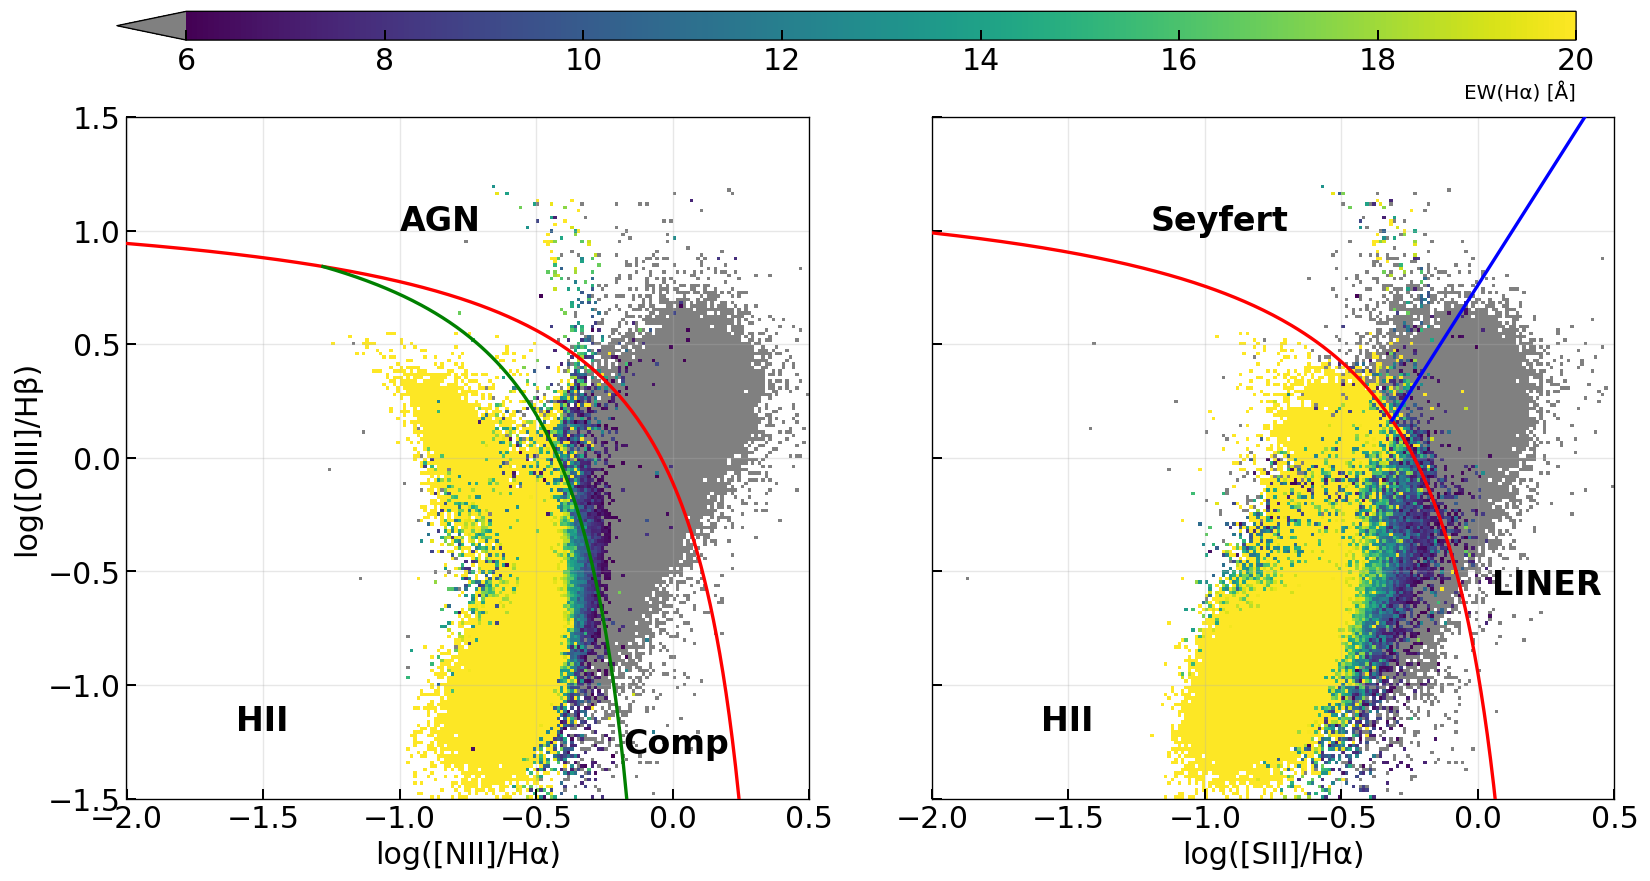


Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


In [6]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Combined Analysis: NII and SII diagrams - color by EW(Halpha)
    # Collect all spaxels from all galaxies (no HII-only selection)
    # Use only dust-corrected emission line fluxes; no O/H needed
    # Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
    #                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from pathlib import Path
    from astropy.io import fits


    # BPT reference line functions (for drawing curves only, if desired)
    def kewley01_N2(x):   # max-starburst
        return 0.61/(x-0.47) + 1.19


    def kauff03_N2(x):    # empirical SF upper envelope
        return 0.61/(x-0.05) + 1.30


    def kewley01_S2(x):
        return 0.72/(x-0.32) + 1.30


    def kewley06_Sy_LIN(x):   # Seyfert/LINER division
        return 1.89*x + 0.76


    # Error propagation for BPT ratios (log10 numerator/denominator)
    def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
        with np.errstate(divide='ignore', invalid='ignore'):
            log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
            return log_ratio_err


    # Create x arrays for the theoretical lines (optional overlay)
    x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
    x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
    x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
    x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


    # Get all galaxies from binning files
    galaxies = physics_ready_galaxies(require_ew=True)

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    SIGMA_CONTOUR_MAX = 45.0


    # Collect all spaxels from all galaxies (no HII selection)
    all_logN2 = []
    all_logO3 = []
    all_logS2 = []
    all_ew = []

    # Stats for SFR components
    count_hii = 0
    count_nonhii = 0
    count_unclass = 0
    count_union = 0
    sum_check_total = 0
    sum_check_ok = 0
    sum_check_maxabs = []

    # Stats for SF/NONSF/UNCLASSIFIED1 components
    count_sf = 0
    count_nonsf = 0
    count_unclass1 = 0
    count_union_sf = 0

    selection_rows = []
    total_base_c1 = 0
    total_hii_only = 0
    total_hii_ew6 = 0
    total_hii_ew6_sigma = 0

    # Error arrays for spaxel subsets
    err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
    err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
    err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
    err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
    err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

    print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
    for gal in galaxies:
        gas_file = further_gas_path(gal)
        bin_file = further_spatial_path(gal)
        ew_file = further_ew_path(gal, EW_FILE_SUFFIX)

        if gas_file.exists() and bin_file.exists() and ew_file.exists():
            with fits.open(gas_file) as h:
                # Load corrected emission line fluxes
                HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
                HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
                OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
                NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
                SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
                SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

                # Load corrected emission line flux errors
                HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
                HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
                OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
                NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
                SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
                SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

                # Load SFR surface density maps
                logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
                logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
                logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
                logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

                # Load SF / NONSF / UNCLASSIFIED1 maps
                logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
                logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
                logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data
                HA6562_SIGMA_OBS = h['HA6562_SIGMA'].data
                HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None
                if HA6562_SIGMA_CORR is None:
                    raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_file.name}')
                if HA6562_SIGMA_CORR.shape != HA6562_SIGMA_OBS.shape:
                    raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {HA6562_SIGMA_CORR.shape} vs SIGMA {HA6562_SIGMA_OBS.shape}')
                sigma2_intrinsic = HA6562_SIGMA_OBS**2 - HA6562_SIGMA_CORR**2
                HA6562_SIGMA = np.full_like(HA6562_SIGMA_OBS, np.nan, dtype=float)
                sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
                HA6562_SIGMA[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])

            with fits.open(ew_file) as h_ew:
                if EW_HDU not in h_ew:
                    print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                    continue
                ew_ha = h_ew[EW_HDU].data

            ew_ha = align_map_to_shape(ew_ha, HA6562_FLUX_corr.shape, label=f"{gal} {EW_HDU}")

            # SFR masks
            hii_mask = np.isfinite(logSigmaSFR_HII)
            nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
            unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
            total_mask = np.isfinite(logSigmaSFR_TOTAL)
            union_mask = hii_mask | nonhii_mask | unclass_mask

            count_hii += np.sum(hii_mask)
            count_nonhii += np.sum(nonhii_mask)
            count_unclass += np.sum(unclass_mask)
            count_union += np.sum(union_mask)

            # SF / NONSF / UNCLASSIFIED1 masks
            sf_mask = np.isfinite(logSigmaSFR_SF)
            nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
            unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
            union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

            count_sf += np.sum(sf_mask)
            count_nonsf += np.sum(nonsf_mask)
            count_unclass1 += np.sum(unclass1_mask)
            count_union_sf += np.sum(union_sf_mask)

            # Check add-up consistency where all components and total are finite
            sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
            if np.any(sum_mask):
                diff = logSigmaSFR_TOTAL[sum_mask] - (
                    logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
                )
                sum_check_total += diff.size
                sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
                sum_check_maxabs.append(np.nanmax(np.abs(diff)))

            # Valid where all corrected line fluxes are finite and positive
            flux_mask = (
                np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
                np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
                np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
                np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
                np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
                np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
            )

            # SFR mask: keep spaxels where any class is finite
            sfr_mask = union_mask

            # EW mask
            ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)
            ew_mask = ew_mask & np.isfinite(HA6562_SIGMA) & (HA6562_SIGMA < 45.0)

            base_c1_mask = flux_mask & union_mask & np.isfinite(ew_ha) & (ew_ha > 0) & np.isfinite(HA6562_SIGMA_CORR) & (HA6562_SIGMA_CORR > 0)
            hii_only_mask = base_c1_mask & np.isfinite(logSigmaSFR_HII)
            hii_ew6_mask = hii_only_mask & np.isfinite(ew_ha) & (ew_ha > 6.0)
            hii_ew6_sigma_mask = hii_ew6_mask & np.isfinite(HA6562_SIGMA) & (HA6562_SIGMA < 45.0)

            n_base_c1 = int(np.sum(base_c1_mask))
            n_hii_only = int(np.sum(hii_only_mask))
            n_hii_ew6 = int(np.sum(hii_ew6_mask))
            n_hii_ew6_sigma = int(np.sum(hii_ew6_sigma_mask))
            selection_rows.append((gal, n_base_c1, n_hii_only, n_hii_ew6, n_hii_ew6_sigma))
            total_base_c1 += n_base_c1
            total_hii_only += n_hii_only
            total_hii_ew6 += n_hii_ew6
            total_hii_ew6_sigma += n_hii_ew6_sigma

            # Combined mask for plotting
            valid_mask = flux_mask & sfr_mask & ew_mask
            n_pixels = np.sum(valid_mask)
            print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

            HB_common = HB4861_FLUX_corr[valid_mask]
            HA_common = HA6562_FLUX_corr[valid_mask]
            OIII_common = OIII5006_FLUX_corr[valid_mask]
            NII_common = NII6583_FLUX_corr[valid_mask]
            SII6716_common = SII6716_FLUX_corr[valid_mask]
            SII6730_common = SII6730_FLUX_corr[valid_mask]
            EW_common = ew_ha[valid_mask]

            # Calculate line ratios for all valid spaxels
            logN2 = np.log10(NII_common / HA_common)
            logO3 = np.log10(OIII_common / HB_common)
            logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

            all_logN2.extend(logN2.flatten())
            all_logO3.extend(logO3.flatten())
            all_logS2.extend(logS2.flatten())
            all_ew.extend(EW_common.flatten())

            # Error propagation for spaxel subsets
            err_mask = (
                np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
                np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
                np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
                np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
                np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
                np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
            )

            def collect_errs(sub_mask, out_N2, out_S2, out_O3):
                valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
                if np.any(valid_err_mask):
                    hb = HB4861_FLUX_corr[valid_err_mask]
                    ha = HA6562_FLUX_corr[valid_err_mask]
                    o3 = OIII5006_FLUX_corr[valid_err_mask]
                    n2 = NII6583_FLUX_corr[valid_err_mask]
                    s2_1 = SII6716_FLUX_corr[valid_err_mask]
                    s2_2 = SII6730_FLUX_corr[valid_err_mask]

                    hb_err = HB4861_FLUX_ERR[valid_err_mask]
                    ha_err = HA6562_FLUX_ERR[valid_err_mask]
                    o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                    n2_err = NII6583_FLUX_ERR[valid_err_mask]
                    s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                    s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                    s2 = s2_1 + s2_2
                    s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                    err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                    err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                    err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                    out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                    out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                    out_O3.extend(err_logO3[np.isfinite(err_logO3)])

            collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
            collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
            collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
            collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
            collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
        else:
            missing_parts = []
            if not gas_file.exists():
                missing_parts.append(gas_file.name)
            if not bin_file.exists():
                missing_parts.append(bin_file.name)
            if not ew_file.exists():
                missing_parts.append(ew_file.name)
            print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

    # Convert to numpy arrays
    all_logN2 = np.array(all_logN2)
    all_logO3 = np.array(all_logO3)
    all_logS2 = np.array(all_logS2)
    all_ew = np.array(all_ew)

    if len(all_logN2) == 0:
        raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
    if len(all_ew) != len(all_logN2):
        raise RuntimeError('EW array length mismatch with BPT arrays.')

    # Report SFR component stats
    print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
    if count_union > 0:
        print('\nSFR component counts (finite spaxels, all galaxies combined):')
        print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
        print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
        print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

    if count_union > 0:
        print('\nSF component counts (finite spaxels, all galaxies combined):')
        print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
        print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
        print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

    if sum_check_total > 0:
        max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
        print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
        print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
        print(f'  Max |Δ|: {max_abs_diff:.3e}')

    def frac(numerator, denominator):
        return np.nan if denominator == 0 else numerator / denominator

    print('\nSelection chain (per galaxy):')
    print('  Base(Cell1) -> HII -> HII+EW>6 -> HII+EW>6+sigma_int<45')
    header_sel = (
        f"{'Galaxy':<10} {'Base(C1)':>10} {'HII':>10} {'f(HII)':>10} "
        f"{'HII+EW>6':>12} {'f(HII+EW)':>12} {'HII+EW+sig<45':>16} {'f(final)':>10}"
    )
    print(header_sel)
    print('-' * len(header_sel))
    for gal_sel, n_base_sel, n_hii_sel, n_hii_ew_sel, n_hii_ew_sig_sel in selection_rows:
        print(
            f"{gal_sel:<10} {n_base_sel:10d} {n_hii_sel:10d} {frac(n_hii_sel, n_base_sel):10.4f} "
            f"{n_hii_ew_sel:12d} {frac(n_hii_ew_sel, n_base_sel):12.4f} {n_hii_ew_sig_sel:16d} {frac(n_hii_ew_sig_sel, n_base_sel):10.4f}"
        )
    print('-' * len(header_sel))
    print(
        f"{'ALL':<10} {total_base_c1:10d} {total_hii_only:10d} {frac(total_hii_only, total_base_c1):10.4f} "
        f"{total_hii_ew6:12d} {frac(total_hii_ew6, total_base_c1):12.4f} {total_hii_ew6_sigma:16d} {frac(total_hii_ew6_sigma, total_base_c1):10.4f}"
    )

    # Mean log-errors for requested subsets

    def mean_or_nan(arr):
        return np.nanmean(arr) if len(arr) > 0 else np.nan

    print('\nMean log-error (spaxel subsets):')
    print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
    print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
    print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
    print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
    print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

    # Create diagrams for all spaxels (2D EW color)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    plt.subplots_adjust(wspace=0.18, top=0.82)

    import copy

    cmap_ew = copy.copy(plt.get_cmap('viridis'))
    cmap_ew.set_under('grey')

    # Binning and ranges
    xlim = (-2.0, 0.5)
    ylim = (-1.5, 1.5)
    bins_2d = 200
    min_count_per_bin = 3
    vmin_ew = 6.0
    vmax_ew = 20.0

    # NII panel EW grid
    hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
        all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
    )
    sum_ew_N2, _, _ = np.histogram2d(
        all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
    )
    mean_ew_N2 = np.divide(
        sum_ew_N2,
        hist_N2,
        out=np.full_like(sum_ew_N2, np.nan, dtype=float),
        where=hist_N2 > 0,
    )
    mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

    # SII panel EW grid
    hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
        all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
    )
    sum_ew_S2, _, _ = np.histogram2d(
        all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
    )
    mean_ew_S2 = np.divide(
        sum_ew_S2,
        hist_S2,
        out=np.full_like(sum_ew_S2, np.nan, dtype=float),
        where=hist_S2 > 0,
    )
    mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

    # NII diagram
    ax = axes[0]
    img_N2 = ax.pcolormesh(
        xedges_N2,
        yedges_N2,
        np.ma.masked_invalid(mean_ew_N2.T),
        cmap=cmap_ew,
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading='auto',
        edgecolors='face',
        linewidths=0
    )

    # Optional: overlay BPT curves as reference only
    ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
    ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

    ax.set_xlabel('log([NII]/Hα)', fontsize=18)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
    ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
    ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # SII diagram
    ax = axes[1]
    img_S2 = ax.pcolormesh(
        xedges_S2,
        yedges_S2,
        np.ma.masked_invalid(mean_ew_S2.T),
        cmap=cmap_ew,
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading='auto',
        edgecolors='face',
        linewidths=0
    )

    ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
    ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

    ax.set_xlabel('log([SII]/Hα)', fontsize=18)
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='y', labelleft=False)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
    ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
    ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Shared colorbar (top, spanning both panels)
    cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
    cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal', extend='min')
    cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
    cbar.ax.tick_params(labelsize=18)

    # Save figures
    output_dir = Path('Plot_Paper_1')
    output_dir.mkdir(parents=True, exist_ok=True)
    # fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
    # fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
    plt.show()

    print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
    print('Galaxies included: ' + ', '.join(galaxies))
else:
    print("Skipped copied previous-project analysis cell 3: no nested *_further mass/SFR/OH+EW products are ready yet.")


  NGC4567_8 inherits stage 1 because NGC4567 and NGC4568 share that stage.
Infall classification loaded:
  Pre-peak (1): NGC4189, NGC4192, NGC4222, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4396, NGC4535, NGC4567, NGC4567_8, NGC4568
  Close-to-peak (2): NGC4298, NGC4302, NGC4330, NGC4388, NGC4402, NGC4424, NGC4501, NGC4522, NGC4654, NGC4694
  Post-peak (3): IC3392, NGC4064, NGC4216, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4548, NGC4569, NGC4579, NGC4580, NGC4606, NGC4607, NGC4689, NGC4698
Colour-coding by infall stage
  IC3392: 13885 common HII pixels, stage 3 (Post-peak)
  NGC4064: 6652 common HII pixels, stage 3 (Post-peak)
  NGC4189: 97706 common HII pixels, stage 1 (Pre-peak)
  NGC4192: 145774 common HII pixels, stage 1 (Pre-peak)
  NGC4254: 680597 common HII pixels, stage 1 (Pre-peak)
  NGC4293: 505 common HII pixels, stage 3 (Post-peak)
  NGC4294: 69156 common HII pixels, stage 1 (Pre-peak)
  NGC4298: 144550 common HII pixels, stage 2 (Close-to-pea

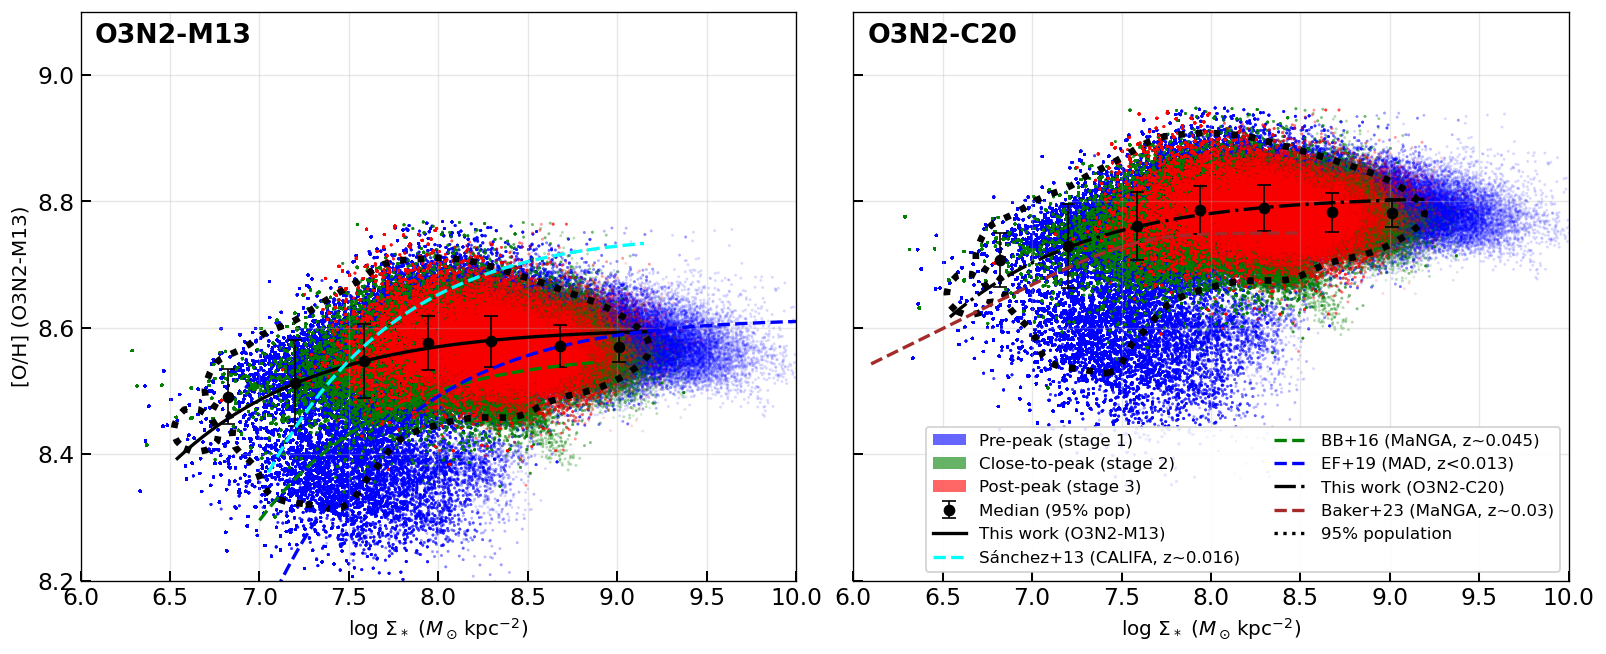


COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)
Colour-coded by infall stage (B=pre-peak, G=close-to-peak, R=post-peak)
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Excluded: NGC4383

Final sample:
  Number of common HII spaxels: 2826356
  Stage 1 (Pre-peak       ): 1987221 spaxels
  Stage 2 (Close-to-peak  ): 583770 spaxels
  Stage 3 (Post-peak      ): 255365 spaxels
  EW(Ha) cut: > 6 Å


In [7]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # rMZR comparison: O3N2-M13 vs O3N2-C20 (HII only)
    # Colour-coded by infall stage from mauve_master_wiki_newclass.fits
    #   1 = pre-peak   → Blue
    #   2 = close-to-peak → Green
    #   3 = post-peak  → Red
    #
    # Two-panel layout (same as cell 15 above, but scatter instead of 2D hist):
    #   Left : rMZR scatter (O3N2-M13) with literature curves
    #   Right: rMZR scatter (O3N2-C20) with Baker+23 curve
    # ------------------------------------------------------------------

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    from pathlib import Path
    from astropy.io import fits

    import scipy.ndimage as ndimage
    from scipy.optimize import curve_fit


    # ------------------------------------------------------------------
    # Config
    # ------------------------------------------------------------------

    EW_FILE_SUFFIX = "_proxy_EW_maps.fits"
    EW_HDU = "PROXY_EWHA"
    EW_MIN = 6.0

    EXCLUDED_GALAXIES = {"NGC4383"}

    COMMON_YLIM = (8.2, 9.1)
    XRANGE_RMZR = (6.0, 10.0)

    NBINS_DENSITY = 100
    DENSITY_SIGMA = 2.0

    BIN_WIDTH = 0.4
    MIN_PIXELS_PER_BIN = 20

    # Infall stage colours: BGR
    INFALL_COLORS = {1: "blue", 2: "green", 3: "red"}
    INFALL_LABELS = {1: "Pre-peak", 2: "Close-to-peak", 3: "Post-peak"}


    # ------------------------------------------------------------------
    # Load infall classification
    # ------------------------------------------------------------------

    infall_fits = Path("mauve_master_wiki_newclass.fits")
    with fits.open(infall_fits) as hdul:
        tbl = hdul[1].data
        infall_class_dict = {
            row["Galaxy"].strip(): int(row["class"])
            for row in tbl
        }
    infall_class_dict = add_combined_infall_classes(infall_class_dict)
    print(
        f"  NGC4567_8 inherits stage {infall_class_dict['NGC4567_8']} because "
        "NGC4567 and NGC4568 share that stage."
    )
    print("Infall classification loaded:")
    for cls_val in [1, 2, 3]:
        gals = [g for g, c in infall_class_dict.items() if c == cls_val]
        print(f"  {INFALL_LABELS[cls_val]} ({cls_val}): {', '.join(sorted(gals))}")


    # ------------------------------------------------------------------
    # Helper functions (same as cell 15)
    # ------------------------------------------------------------------

    def require_hdu(hdul, hdu_name, filename):
        """Raise a clear error if a required HDU is missing."""
        if hdu_name not in hdul:
            raise KeyError(f"Missing HDU '{hdu_name}' in {filename}")
        return hdul[hdu_name].data


    def load_maps(gal):
        """Load stellar mass surface density and both O3N2 metallicity maps."""
        bin_file = further_spatial_path(gal)
        gas_file = further_gas_path(gal)
        ew_file = further_ew_path(gal, EW_FILE_SUFFIX)

        if not bin_file.exists():
            raise FileNotFoundError(f"Missing file: {bin_file}")
        if not gas_file.exists():
            raise FileNotFoundError(f"Missing file: {gas_file}")
        if not ew_file.exists():
            raise FileNotFoundError(f"Missing file: {ew_file}")

        with fits.open(bin_file) as h:
            logSigmaM = require_hdu(h, "LOGMASS_SURFACE_DENSITY", bin_file)

        with fits.open(gas_file) as h:
            oh_o3n2_m13 = require_hdu(h, "O_H_O3N2_M13_HII", gas_file)
            oh_o3n2_c20 = require_hdu(h, "O_H_O3N2_C20_HII", gas_file)

        with fits.open(ew_file) as h:
            ew_ha = require_hdu(h, EW_HDU, ew_file)
        ew_ha = align_map_to_shape(ew_ha, oh_o3n2_m13.shape, label=f"{gal} {EW_HDU}")

        return logSigmaM, oh_o3n2_m13, oh_o3n2_c20, ew_ha


    def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
        """
        Calculate median and standard deviation in x bins.

        Keeps only bins with at least min_pixels finite y-values.
        """
        finite = np.isfinite(x_data) & np.isfinite(y_data)
        x_data = np.asarray(x_data)[finite]
        y_data = np.asarray(y_data)[finite]

        if len(x_data) == 0:
            return (
                np.array([]),
                np.array([]),
                np.array([]),
                np.array([]),
                np.array([]),
            )

        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

        medians = []
        stds = []
        counts = []
        valid_centers = []
        valid_bin_indices = []

        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (x_data >= bin_start) & (x_data < bin_end)

            x_in_bin = x_data[in_bin]
            y_in_bin = y_data[in_bin]

            if np.sum(np.isfinite(y_in_bin)) >= min_pixels:
                valid_centers.append(np.nanmedian(x_in_bin))
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(np.sum(np.isfinite(y_in_bin)))
                valid_bin_indices.append(i)

        return (
            np.asarray(valid_centers),
            np.asarray(medians),
            np.asarray(stds),
            np.asarray(counts),
            np.asarray(valid_bin_indices),
        )


    def mzr_model(x, a, b, c):
        """Sánchez-style rMZR functional form."""
        return a + b * (x - c) * np.exp(-(x - c))


    def compute_density_mask(
        x_vals,
        y_vals,
        x_range,
        y_range,
        nbins=100,
        sigma=2.0,
        return_contour=False,
    ):
        """
        Return mask for points inside the 95% density contour.

        The density is estimated from a smoothed 2D histogram in the requested range.
        """
        x_vals = np.asarray(x_vals)
        y_vals = np.asarray(y_vals)

        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)

        empty_mask = np.zeros_like(x_vals, dtype=bool)

        if not np.any(mask_finite):
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        x = x_vals[mask_finite]
        y = y_vals[mask_finite]

        H, xedges, yedges = np.histogram2d(
            x,
            y,
            bins=nbins,
            range=[x_range, y_range],
        )

        if np.sum(H) <= 0:
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)

        if H_cumsum[-1] <= 0:
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
        level_idx = min(level_idx, len(H_flat) - 1)
        level_95 = H_flat[level_idx]

        x_centers = 0.5 * (xedges[:-1] + xedges[1:])
        y_centers = 0.5 * (yedges[:-1] + yedges[1:])

        X, Y = np.meshgrid(x_centers, y_centers)

        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins

        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5

        densities = ndimage.map_coordinates(
            H_smooth,
            [x_idx, y_idx],
            order=1,
            mode="constant",
            cval=0.0,
        )

        mask_local = densities >= level_95

        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local

        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)

        return full_mask


    def plot_literature_mzr_fits(ax, show_legend=True):
        """Overlay literature rMZR curves: Sánchez+13, Barrera-Ballesteros+16, Erroz-Ferrer+19."""
        plot_data = []

        x_sanchez = np.linspace(7.05, 9.15, 200)
        a5, b5, c5 = 8.74, 0.013, 9.50
        y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
        plot_data.append(
            (
                x_sanchez,
                y_sanchez13,
                "Sánchez+13 (CALIFA, z~0.016)",
                "--",
                "cyan",
            )
        )

        x_bb = np.linspace(7.0, 8.9, 200)
        a2, b2, c2 = 8.55, 0.014, 9.14
        y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
        plot_data.append(
            (
                x_bb,
                y_bb16,
                "BB+16 (MaNGA, z~0.045)",
                "--",
                "green",
            )
        )

        x_ef = np.linspace(6.5, 10.0, 200)
        a4, b4, c4 = 8.61, 0.008, 10.0
        y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
        plot_data.append(
            (
                x_ef,
                y_ef19,
                "EF+19 (MAD, z<0.013)",
                "--",
                "blue",
            )
        )

        handles = []

        for x, y, label, linestyle, color in plot_data:
            line, = ax.plot(
                x,
                y,
                label=label if show_legend else None,
                linewidth=2,
                linestyle=linestyle,
                color=color,
            )
            handles.append(line)

        return handles


    def plot_literature_baker(ax, show_legend=True):
        """Overlay Baker+23 collapsed rFMR curve."""
        x_baker = np.linspace(6.1, 8.5, 200)

        logSigmaSFR_ref = -2.0

        Z0_B = 8.75
        gamma_B = 0.14
        phi_B = 2.73
        m0_B = 8.58
        m1_B = 0.50

        logM0_B = m0_B + m1_B * logSigmaSFR_ref
        M0_B = 10.0 ** logM0_B
        Sigma_star_B = 10.0 ** x_baker

        y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(
            1.0 + (Sigma_star_B / M0_B) ** (-phi_B)
        )

        line, = ax.plot(
            x_baker,
            y_baker23,
            label="Baker+23 (MaNGA, z~0.03)" if show_legend else None,
            linewidth=2,
            linestyle="--",
            color="brown",
        )

        return [line]


    def safe_fit_and_plot(ax, x, y, linestyle, label):
        """Fit mzr_model to x/y and plot the result."""
        finite = np.isfinite(x) & np.isfinite(y)
        x_fit_data = np.asarray(x)[finite]
        y_fit_data = np.asarray(y)[finite]

        if len(x_fit_data) < 10:
            print(f"{label}: not enough points for fitting.")
            return None, None, None, None

        p0 = [8.5, 0.0002, 12.5]
        bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])

        try:
            popt, pcov = curve_fit(
                mzr_model,
                x_fit_data,
                y_fit_data,
                p0=p0,
                bounds=bounds,
                maxfev=5000,
            )

            x_model = np.linspace(np.nanmin(x_fit_data), np.nanmax(x_fit_data), 150)
            y_model = mzr_model(x_model, *popt)

            line, = ax.plot(
                x_model,
                y_model,
                linestyle,
                linewidth=2,
                color="k",
                label=label,
            )

            perr = np.sqrt(np.diag(pcov))

            print(
                f"{label}: "
                f"a={popt[0]:.3f} ± {perr[0]:.3f}, "
                f"b={popt[1]:.5f} ± {perr[1]:.5f}, "
                f"c={popt[2]:.3f} ± {perr[2]:.3f}"
            )

            return line, popt, pcov, (x_model, y_model)

        except Exception as e:
            print(f"{label} fit failed: {e}")
            return None, None, None, None


    # ------------------------------------------------------------------
    # Collect data — now per-galaxy to track infall stage
    # ------------------------------------------------------------------

    galaxies = physics_ready_galaxies(require_ew=True)

    included_galaxies = []

    # Store per-stage arrays
    stage_logSigmaM = {1: [], 2: [], 3: []}
    stage_oh_m13 = {1: [], 2: [], 3: []}
    stage_oh_c20 = {1: [], 2: [], 3: []}

    # Also keep combined arrays for fitting / density mask
    all_logSigmaM_HII = []
    all_oh_o3n2_m13_HII = []
    all_oh_o3n2_c20_HII = []

    print("=" * 80)
    print("Collecting common HII spaxels for O3N2-M13 and O3N2-C20...")
    print("Colour-coding by infall stage")
    print("=" * 80)

    for gal in galaxies:
        if gal in EXCLUDED_GALAXIES:
            print(f"  {gal}: excluded from analysis")
            continue

        try:
            logSigmaM, oh_o3n2_m13, oh_o3n2_c20, ew_ha = load_maps(gal)
        except Exception as e:
            print(f"  {gal}: skipped - {e}")
            continue

        shapes = {
            "logSigmaM": logSigmaM.shape,
            "O3N2-M13": oh_o3n2_m13.shape,
            "O3N2-C20": oh_o3n2_c20.shape,
            "EW(Ha)": ew_ha.shape,
        }

        if len(set(shapes.values())) != 1:
            print(f"  {gal}: skipped - shape mismatch: {shapes}")
            continue

        common_mask = (
            np.isfinite(logSigmaM)
            & np.isfinite(oh_o3n2_m13)
            & np.isfinite(oh_o3n2_c20)
            & np.isfinite(ew_ha)
            & (ew_ha > EW_MIN)
        )

        n_common = int(np.sum(common_mask))

        # Look up infall stage
        stage = infall_class_dict.get(gal, None)
        if stage is None:
            print(f"  {gal}: skipped - no infall class in master table")
            continue

        print(f"  {gal}: {n_common} common HII pixels, stage {stage} ({INFALL_LABELS[stage]})")

        if n_common == 0:
            continue

        included_galaxies.append(gal)

        sigM_flat = logSigmaM[common_mask].ravel()
        m13_flat = oh_o3n2_m13[common_mask].ravel()
        c20_flat = oh_o3n2_c20[common_mask].ravel()

        stage_logSigmaM[stage].extend(sigM_flat)
        stage_oh_m13[stage].extend(m13_flat)
        stage_oh_c20[stage].extend(c20_flat)

        all_logSigmaM_HII.extend(sigM_flat)
        all_oh_o3n2_m13_HII.extend(m13_flat)
        all_oh_o3n2_c20_HII.extend(c20_flat)

    # Convert to arrays
    for s in [1, 2, 3]:
        stage_logSigmaM[s] = np.asarray(stage_logSigmaM[s])
        stage_oh_m13[s] = np.asarray(stage_oh_m13[s])
        stage_oh_c20[s] = np.asarray(stage_oh_c20[s])

    all_logSigmaM_HII = np.asarray(all_logSigmaM_HII)
    all_oh_o3n2_m13_HII = np.asarray(all_oh_o3n2_m13_HII)
    all_oh_o3n2_c20_HII = np.asarray(all_oh_o3n2_c20_HII)

    print("\n" + "-" * 80)
    print("Final array lengths:")
    print(f"  Total            : {len(all_logSigmaM_HII)}")
    for s in [1, 2, 3]:
        print(f"  Stage {s} ({INFALL_LABELS[s]:15s}): {len(stage_logSigmaM[s])}")
    print("-" * 80)

    if len(all_logSigmaM_HII) == 0:
        raise RuntimeError("No common HII spaxels found. Check EW files, HDU names, and input maps.")


    # ------------------------------------------------------------------
    # Plot setup
    # ------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharex=True,
        sharey=True,
    )

    plt.subplots_adjust(wspace=0.08, top=0.90)

    ax_left, ax_right = axes


    # ------------------------------------------------------------------
    # Left panel: O3N2-M13 — scatter by infall stage
    # ------------------------------------------------------------------

    print("\n--- Left panel: O3N2-M13 rMZR (infall-stage coloured) ---")

    # Plot each stage in order (post-peak first so pre-peak is on top)
    for stage in [1, 2, 3]:
        if len(stage_logSigmaM[stage]) == 0:
            continue
        ax_left.scatter(
            stage_logSigmaM[stage],
            stage_oh_m13[stage],
            c=INFALL_COLORS[stage],
            s=3,
            alpha=0.15,
            edgecolors="none",
            rasterized=True,
            label=f"{INFALL_LABELS[stage]} ({len(stage_logSigmaM[stage])} spx)",
        )

    mask_95_m13, level_95_m13, contour_data_m13 = compute_density_mask(
        all_logSigmaM_HII,
        all_oh_o3n2_m13_HII,
        XRANGE_RMZR,
        COMMON_YLIM,
        nbins=NBINS_DENSITY,
        sigma=DENSITY_SIGMA,
        return_contour=True,
    )

    if contour_data_m13 is not None and level_95_m13 is not None and level_95_m13 > 0:
        ax_left.contour(
            contour_data_m13[0],
            contour_data_m13[1],
            contour_data_m13[2].T,
            levels=[level_95_m13],
            colors="k",
            linewidths=4,
            linestyles=":",
        )

    mass_centers_m13, medians_m13, stds_m13, counts_m13, _ = calculate_binned_stats(
        all_logSigmaM_HII[mask_95_m13],
        all_oh_o3n2_m13_HII[mask_95_m13],
        bin_width=BIN_WIDTH,
        min_pixels=MIN_PIXELS_PER_BIN,
    )

    median_left = None

    if len(mass_centers_m13) >= 3:
        median_left = ax_left.errorbar(
            mass_centers_m13,
            medians_m13,
            yerr=stds_m13,
            fmt="o",
            color="k",
            markersize=6,
            linewidth=1,
            capsize=4,
            label="Median (95% pop)",
        )

    fit_line_left, popt_m13, pcov_m13, fit_data_m13 = safe_fit_and_plot(
        ax_left,
        all_logSigmaM_HII[mask_95_m13],
        all_oh_o3n2_m13_HII[mask_95_m13],
        "-",
        "This work (O3N2-M13)",
    )

    lit_handles_left = plot_literature_mzr_fits(ax_left, show_legend=True)

    ax_left.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
    ax_left.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
    ax_left.set_xlim(*XRANGE_RMZR)
    ax_left.set_ylim(*COMMON_YLIM)
    ax_left.grid(True, alpha=0.3)

    ax_left.text(
        0.02,
        0.98,
        "O3N2-M13",
        transform=ax_left.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
    )


    # ------------------------------------------------------------------
    # Right panel: O3N2-C20 — scatter by infall stage
    # ------------------------------------------------------------------

    print("\n--- Right panel: O3N2-C20 rMZR (infall-stage coloured) ---")

    for stage in [1, 2, 3]:
        if len(stage_logSigmaM[stage]) == 0:
            continue
        ax_right.scatter(
            stage_logSigmaM[stage],
            stage_oh_c20[stage],
            c=INFALL_COLORS[stage],
            s=3,
            alpha=0.15,
            edgecolors="none",
            rasterized=True,
        )

    mask_95_c20, level_95_c20, contour_data_c20 = compute_density_mask(
        all_logSigmaM_HII,
        all_oh_o3n2_c20_HII,
        XRANGE_RMZR,
        COMMON_YLIM,
        nbins=NBINS_DENSITY,
        sigma=DENSITY_SIGMA,
        return_contour=True,
    )

    if contour_data_c20 is not None and level_95_c20 is not None and level_95_c20 > 0:
        ax_right.contour(
            contour_data_c20[0],
            contour_data_c20[1],
            contour_data_c20[2].T,
            levels=[level_95_c20],
            colors="k",
            linewidths=4,
            linestyles=":",
        )

    mass_centers_c20, medians_c20, stds_c20, counts_c20, _ = calculate_binned_stats(
        all_logSigmaM_HII[mask_95_c20],
        all_oh_o3n2_c20_HII[mask_95_c20],
        bin_width=BIN_WIDTH,
        min_pixels=MIN_PIXELS_PER_BIN,
    )

    median_right = None

    if len(mass_centers_c20) >= 3:
        median_right = ax_right.errorbar(
            mass_centers_c20,
            medians_c20,
            yerr=stds_c20,
            fmt="o",
            color="k",
            markersize=6,
            linewidth=1,
            capsize=4,
            label=None,
        )

    fit_line_right, popt_c20, pcov_c20, fit_data_c20 = safe_fit_and_plot(
        ax_right,
        all_logSigmaM_HII[mask_95_c20],
        all_oh_o3n2_c20_HII[mask_95_c20],
        "-.",
        "This work (O3N2-C20)",
    )

    baker_handles = plot_literature_baker(ax_right, show_legend=True)

    ax_right.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
    ax_right.set_xlim(*XRANGE_RMZR)
    ax_right.set_ylim(*COMMON_YLIM)
    ax_right.grid(True, alpha=0.3)

    ax_right.text(
        0.02,
        0.98,
        "O3N2-C20",
        transform=ax_right.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
    )


    # ------------------------------------------------------------------
    # Consolidated legend
    # ------------------------------------------------------------------

    contour_handle = Line2D(
        [0],
        [0],
        color="k",
        linestyle=":",
        linewidth=2,
        label="95% population",
    )

    # Infall stage legend patches
    infall_patches = [
        Patch(facecolor=INFALL_COLORS[s], alpha=0.6, label=f"{INFALL_LABELS[s]} (stage {s})")
        for s in [1, 2, 3]
    ]

    legend_handles = list(infall_patches)

    if median_left is not None:
        legend_handles.append(median_left)

    if fit_line_left is not None:
        legend_handles.append(fit_line_left)

    for h in lit_handles_left:
        legend_handles.append(h)

    if fit_line_right is not None:
        legend_handles.append(fit_line_right)

    for h in baker_handles:
        legend_handles.append(h)

    legend_handles.append(contour_handle)

    ax_right.legend(
        handles=legend_handles,
        loc="lower right",
        fontsize=10,
        framealpha=0.9,
        ncol=2,
    )


    # ------------------------------------------------------------------
    # Save and show
    # ------------------------------------------------------------------

    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_infall_EW.png', dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_infall_EW.pdf', bbox_inches='tight')
    plt.show()


    # ------------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------------

    print("\n" + "=" * 80)
    print("COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)")
    print("Colour-coded by infall stage (B=pre-peak, G=close-to-peak, R=post-peak)")
    print("=" * 80)

    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(EXCLUDED_GALAXIES))}")

    print("\nFinal sample:")
    print(f"  Number of common HII spaxels: {len(all_logSigmaM_HII)}")
    for s in [1, 2, 3]:
        print(f"  Stage {s} ({INFALL_LABELS[s]:15s}): {len(stage_logSigmaM[s])} spaxels")
    print(f"  EW(Ha) cut: > {EW_MIN:g} Å")
    print("=" * 80)
else:
    print("Skipped infall-coloured rMZR cell: no nested *_further mass/SFR/OH+EW products are ready yet.")


### Combined rMZR + Z_gas-Σ_SFR — coloured by infall stage

Same 2×2 layout as cell above, but scatter points and median trends are coloured by
infall stage: Blue = pre-peak (1), Green = close-to-peak (2), Red = post-peak (3).

### Resolved star-forming main sequence (rSFMS) — coloured by infall stage

This panel compares HII-region $\log\,\Sigma_{\mathrm{SFR}}$ with
$\log\,\Sigma_*$ using the same EW(H$\alpha$) > 6 Å selection and infall-stage
colours as the rMZR panel. Solid lines and shaded bands show the median and
16th–84th percentile range in common 0.4-dex stellar-mass bins.

NGC4567_8 inherits stage 1 because NGC4567 and NGC4568 share that stage.
  IC3392: 13897 HII spaxels, stage 3 (Post-peak)
  NGC4064: 6652 HII spaxels, stage 3 (Post-peak)
  NGC4189: 97706 HII spaxels, stage 1 (Pre-peak)
  NGC4192: 145794 HII spaxels, stage 1 (Pre-peak)
  NGC4254: 680597 HII spaxels, stage 1 (Pre-peak)
  NGC4293: 505 HII spaxels, stage 3 (Post-peak)
  NGC4294: 69207 HII spaxels, stage 1 (Pre-peak)
  NGC4298: 144628 HII spaxels, stage 2 (Close-to-peak)
  NGC4302: 33440 HII spaxels, stage 2 (Close-to-peak)
  NGC4321: 465049 HII spaxels, stage 1 (Pre-peak)
  NGC4330: 35729 HII spaxels, stage 2 (Close-to-peak)
  NGC4351: 30810 HII spaxels, stage 1 (Pre-peak)
  NGC4380: 64404 HII spaxels, stage 3 (Post-peak)
  NGC4383: excluded from analysis
  NGC4388: 18864 HII spaxels, stage 2 (Close-to-peak)
  NGC4394: 31915 HII spaxels, stage 3 (Post-peak)
  NGC4396: 86178 HII spaxels, stage 1 (Pre-peak)
  NGC4402: 48104 HII spaxels, stage 2 (Close-to-peak)
  NGC4405: 13569 HII spaxels, 

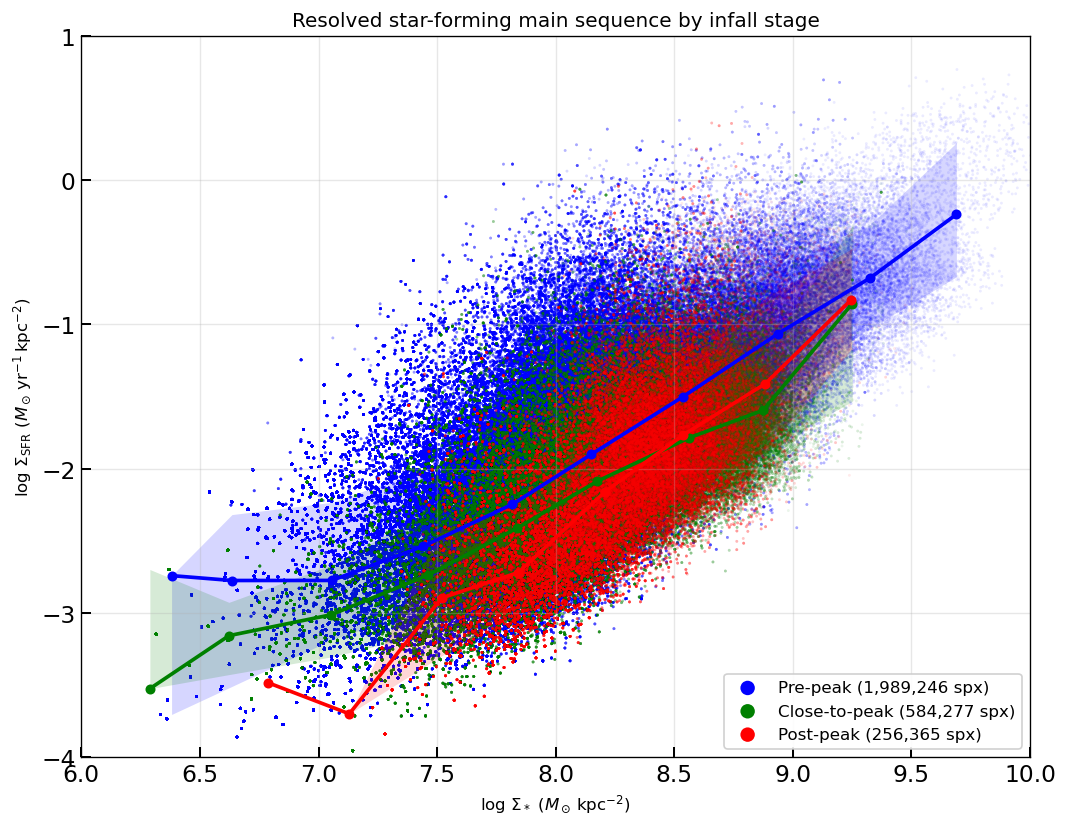


rSFMS sample by infall stage:
  Stage 1 (Pre-peak       ): 1,989,246 spaxels
  Stage 2 (Close-to-peak  ): 584,277 spaxels
  Stage 3 (Post-peak      ): 256,365 spaxels
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
EW(Ha) cut: > 6 Å


In [8]:
# rSFMS by infall stage, using HII-only SFR surface-density maps.
RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.4
RSFMS_MIN_PIXELS_PER_BIN = 20

rsfms_infall_colors = {1: "blue", 2: "green", 3: "red"}
rsfms_infall_labels = {1: "Pre-peak", 2: "Close-to-peak", 3: "Post-peak"}

with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    rsfms_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
rsfms_infall_class = add_combined_infall_classes(rsfms_infall_class)
print(
    f"NGC4567_8 inherits stage {rsfms_infall_class['NGC4567_8']} because "
    "NGC4567 and NGC4568 share that stage."
)

rsfms_ready = (
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
)
rsfms_galaxies = PRODUCTS.index[rsfms_ready].tolist()
stage_logSigmaM_rsfms = {stage: [] for stage in [1, 2, 3]}
stage_logSigmaSFR_rsfms = {stage: [] for stage in [1, 2, 3]}
included_rsfms_galaxies = []

print("Collecting HII spaxels for the rSFMS by infall stage...")
for galaxy in rsfms_galaxies:
    if galaxy in EXCLUDED_GALAXIES:
        print(f"  {galaxy}: excluded from analysis")
        continue

    stage = rsfms_infall_class.get(galaxy)
    if stage not in rsfms_infall_colors:
        print(f"  {galaxy}: skipped - no infall class in master table")
        continue

    try:
        spatial_path = further_spatial_path(galaxy)
        gas_path = further_gas_path(galaxy)
        ew_path = further_ew_path(galaxy, EW_FILE_SUFFIX)
        with fits.open(spatial_path) as hdul:
            log_sigma_m = require_hdu_data(
                hdul, "LOGMASS_SURFACE_DENSITY", spatial_path
            )
        with fits.open(gas_path) as hdul:
            log_sigma_sfr = require_hdu_data(
                hdul, "LOGSFR_SURFACE_DENSITY_HII", gas_path
            )
        with fits.open(ew_path) as hdul:
            ew_ha = require_hdu_data(hdul, EW_HDU, ew_path)

        log_sigma_m = align_map_to_shape(
            log_sigma_m, log_sigma_sfr.shape, label=f"{galaxy} stellar mass"
        )
        ew_ha = align_map_to_shape(
            ew_ha, log_sigma_sfr.shape, label=f"{galaxy} {EW_HDU}"
        )
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    mask = (
        np.isfinite(log_sigma_m)
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
    )
    n_spaxels = int(mask.sum())
    print(
        f"  {galaxy}: {n_spaxels} HII spaxels, "
        f"stage {stage} ({rsfms_infall_labels[stage]})"
    )
    if n_spaxels == 0:
        continue

    included_rsfms_galaxies.append(galaxy)
    stage_logSigmaM_rsfms[stage].extend(log_sigma_m[mask].ravel())
    stage_logSigmaSFR_rsfms[stage].extend(log_sigma_sfr[mask].ravel())

for stage in [1, 2, 3]:
    stage_logSigmaM_rsfms[stage] = np.asarray(stage_logSigmaM_rsfms[stage])
    stage_logSigmaSFR_rsfms[stage] = np.asarray(stage_logSigmaSFR_rsfms[stage])

if not any(stage_logSigmaM_rsfms[stage].size for stage in [1, 2, 3]):
    raise RuntimeError("No valid HII spaxels found for the rSFMS plot.")


def binned_rsfms_percentiles(x, y, bin_edges, min_pixels=20):
    """Return median x/y and the 16th–84th percentile y range per bin."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    x_median, y_median, y16, y84, counts = [], [], [], [], []
    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (x >= left) & (x < right)
        if in_bin.sum() < min_pixels:
            continue
        x_median.append(np.nanmedian(x[in_bin]))
        y_median.append(np.nanmedian(y[in_bin]))
        y16.append(np.nanpercentile(y[in_bin], 16))
        y84.append(np.nanpercentile(y[in_bin], 84))
        counts.append(int(in_bin.sum()))
    return tuple(np.asarray(values) for values in (x_median, y_median, y16, y84, counts))


fig, ax = plt.subplots(figsize=(9, 7))
mass_bins = np.arange(
    RSFMS_XRANGE[0], RSFMS_XRANGE[1] + RSFMS_BIN_WIDTH, RSFMS_BIN_WIDTH
)

for stage in [1, 2, 3]:
    x = stage_logSigmaM_rsfms[stage]
    y = stage_logSigmaSFR_rsfms[stage]
    if x.size == 0:
        continue

    color = rsfms_infall_colors[stage]
    label = rsfms_infall_labels[stage]
    ax.scatter(
        x, y, s=3, alpha=0.08, color=color, edgecolors="none",
        rasterized=True, label=f"{label} ({x.size:,} spx)",
    )

    x_med, y_med, y16, y84, counts = binned_rsfms_percentiles(
        x, y, mass_bins, min_pixels=RSFMS_MIN_PIXELS_PER_BIN
    )
    if x_med.size:
        ax.fill_between(x_med, y16, y84, color=color, alpha=0.16, linewidth=0)
        ax.plot(x_med, y_med, color=color, marker="o", markersize=5, linewidth=2.2)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=r"$\log\,\Sigma_{\mathrm{SFR}} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="lower right", framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_infall_EW.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_infall_EW.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in [1, 2, 3]:
    print(
        f"  Stage {stage} ({rsfms_infall_labels[stage]:15s}): "
        f"{stage_logSigmaM_rsfms[stage].size:,} spaxels"
    )
print(f"Galaxies included: {', '.join(included_rsfms_galaxies)}")
print(f"EW(Ha) cut: > {EW_MIN:g} Å")

### Resolved mass–metallicity relation (rMZR; O3N2–M13) — coloured by infall stage

This single-panel rMZR uses the same infall-stage colours, EW(H$\alpha$) > 6 Å
selection, common 0.4-dex stellar-mass bins, and visual layout as the rSFMS
panel above. The three solid trends and shaded bands show the stage medians and
16th–84th percentile ranges; no second metallicity calibration, literature curve,
or global fit is included.

  IC3392: 13885 HII spaxels, stage 3 (Post-peak)
  NGC4064: 6652 HII spaxels, stage 3 (Post-peak)
  NGC4189: 97706 HII spaxels, stage 1 (Pre-peak)
  NGC4192: 145774 HII spaxels, stage 1 (Pre-peak)
  NGC4254: 680597 HII spaxels, stage 1 (Pre-peak)
  NGC4293: 505 HII spaxels, stage 3 (Post-peak)
  NGC4294: 69156 HII spaxels, stage 1 (Pre-peak)
  NGC4298: 144550 HII spaxels, stage 2 (Close-to-peak)
  NGC4302: 33300 HII spaxels, stage 2 (Close-to-peak)
  NGC4321: 464785 HII spaxels, stage 1 (Pre-peak)
  NGC4330: 35729 HII spaxels, stage 2 (Close-to-peak)
  NGC4351: 30810 HII spaxels, stage 1 (Pre-peak)
  NGC4380: 63740 HII spaxels, stage 3 (Post-peak)
  NGC4383: excluded from analysis
  NGC4388: 18864 HII spaxels, stage 2 (Close-to-peak)
  NGC4394: 31710 HII spaxels, stage 3 (Post-peak)
  NGC4396: 86178 HII spaxels, stage 1 (Pre-peak)
  NGC4402: 47848 HII spaxels, stage 2 (Close-to-peak)
  NGC4405: 13555 HII spaxels, stage 3 (Post-peak)
  NGC4419: 5809 HII spaxels, stage 3 (Post-peak)
  NG

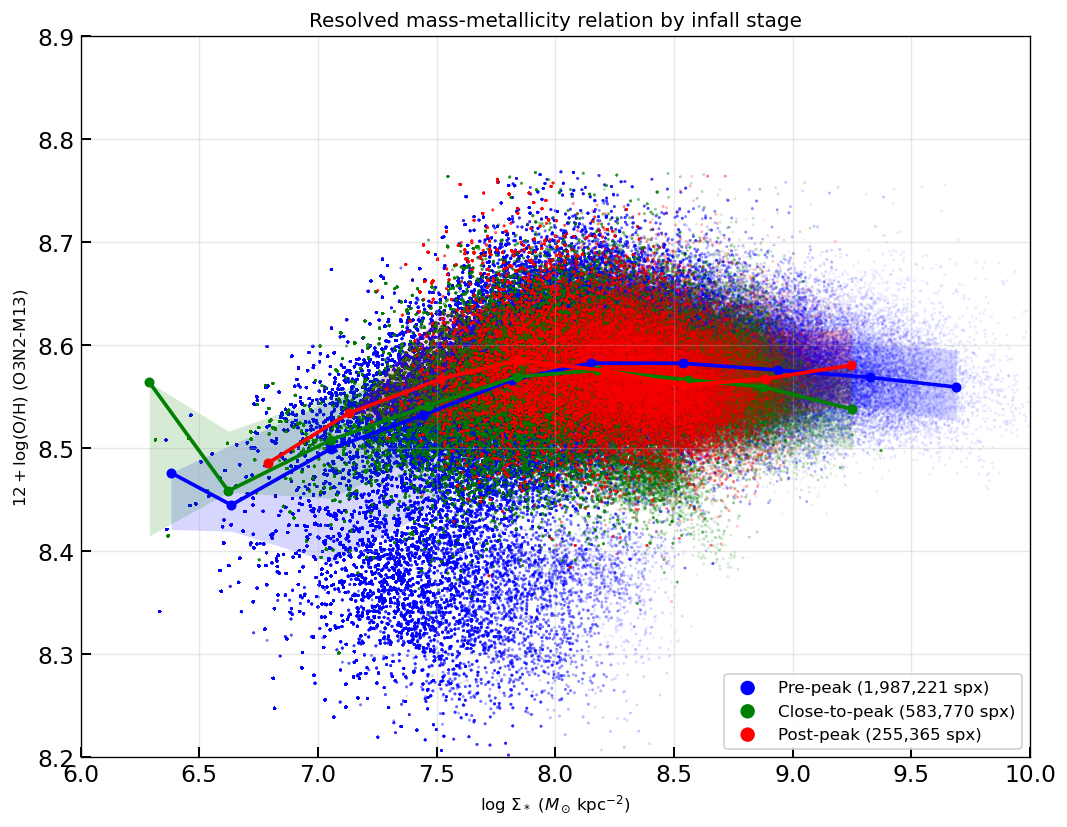


O3N2-M13 rMZR sample by infall stage:
  Stage 1 (Pre-peak       ): 1,987,221 spaxels
  Stage 2 (Close-to-peak  ): 583,770 spaxels
  Stage 3 (Post-peak      ): 255,365 spaxels
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
EW(Ha) cut: > 6 Å


In [9]:
# Standalone O3N2-M13 rMZR by infall stage.
RMZR_M13_XRANGE = (6.0, 10.0)
RMZR_M13_YRANGE = (8.2, 8.9)
RMZR_M13_BIN_WIDTH = 0.4
RMZR_M13_MIN_PIXELS_PER_BIN = 20

rmzr_m13_infall_colors = {1: "blue", 2: "green", 3: "red"}
rmzr_m13_infall_labels = {
    1: "Pre-peak", 2: "Close-to-peak", 3: "Post-peak"
}
with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    rmzr_m13_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
rmzr_m13_infall_class = add_combined_infall_classes(rmzr_m13_infall_class)

rmzr_m13_ready = (
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_o3n2_m13"]
    & PRODUCTS["has_proxy_ew"]
)
rmzr_m13_galaxies = PRODUCTS.index[rmzr_m13_ready].tolist()
stage_logSigmaM_rmzr_m13 = {stage: [] for stage in [1, 2, 3]}
stage_oh_m13_rmzr = {stage: [] for stage in [1, 2, 3]}
included_rmzr_m13_galaxies = []

print("Collecting HII spaxels for the O3N2-M13 rMZR by infall stage...")
for galaxy in rmzr_m13_galaxies:
    if galaxy in EXCLUDED_GALAXIES:
        print(f"  {galaxy}: excluded from analysis")
        continue

    stage = rmzr_m13_infall_class.get(galaxy)
    if stage not in rmzr_m13_infall_colors:
        print(f"  {galaxy}: skipped - no infall class in master table")
        continue

    try:
        spatial_path = further_spatial_path(galaxy)
        gas_path = further_gas_path(galaxy)
        ew_path = further_ew_path(galaxy, EW_FILE_SUFFIX)
        with fits.open(spatial_path) as hdul:
            log_sigma_m = require_hdu_data(
                hdul, "LOGMASS_SURFACE_DENSITY", spatial_path
            )
        with fits.open(gas_path) as hdul:
            oh_m13 = require_hdu_data(hdul, "O_H_O3N2_M13_HII", gas_path)
        with fits.open(ew_path) as hdul:
            ew_ha = require_hdu_data(hdul, EW_HDU, ew_path)

        log_sigma_m = align_map_to_shape(
            log_sigma_m, oh_m13.shape, label=f"{galaxy} stellar mass"
        )
        ew_ha = align_map_to_shape(
            ew_ha, oh_m13.shape, label=f"{galaxy} {EW_HDU}"
        )
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    mask = (
        np.isfinite(log_sigma_m)
        & np.isfinite(oh_m13)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
    )
    n_spaxels = int(mask.sum())
    print(
        f"  {galaxy}: {n_spaxels} HII spaxels, "
        f"stage {stage} ({rmzr_m13_infall_labels[stage]})"
    )
    if n_spaxels == 0:
        continue

    included_rmzr_m13_galaxies.append(galaxy)
    stage_logSigmaM_rmzr_m13[stage].extend(log_sigma_m[mask].ravel())
    stage_oh_m13_rmzr[stage].extend(oh_m13[mask].ravel())

for stage in [1, 2, 3]:
    stage_logSigmaM_rmzr_m13[stage] = np.asarray(
        stage_logSigmaM_rmzr_m13[stage]
    )
    stage_oh_m13_rmzr[stage] = np.asarray(stage_oh_m13_rmzr[stage])

if not any(stage_logSigmaM_rmzr_m13[stage].size for stage in [1, 2, 3]):
    raise RuntimeError("No valid HII spaxels found for the O3N2-M13 rMZR plot.")


def binned_rmzr_m13_percentiles(x, y, bin_edges, min_pixels=20):
    """Return median x/y and the 16th-84th percentile y range per bin."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    x_median, y_median, y16, y84, counts = [], [], [], [], []
    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (x >= left) & (x < right)
        if in_bin.sum() < min_pixels:
            continue
        x_median.append(np.nanmedian(x[in_bin]))
        y_median.append(np.nanmedian(y[in_bin]))
        y16.append(np.nanpercentile(y[in_bin], 16))
        y84.append(np.nanpercentile(y[in_bin], 84))
        counts.append(int(in_bin.sum()))
    return tuple(
        np.asarray(values)
        for values in (x_median, y_median, y16, y84, counts)
    )

fig, ax = plt.subplots(figsize=(9, 7))
mass_bins_rmzr_m13 = np.arange(
    RMZR_M13_XRANGE[0],
    RMZR_M13_XRANGE[1] + RMZR_M13_BIN_WIDTH,
    RMZR_M13_BIN_WIDTH,
)

for stage in [1, 2, 3]:
    x = stage_logSigmaM_rmzr_m13[stage]
    y = stage_oh_m13_rmzr[stage]
    if x.size == 0:
        continue

    color = rmzr_m13_infall_colors[stage]
    label = rmzr_m13_infall_labels[stage]
    ax.scatter(
        x, y, s=3, alpha=0.08, color=color, edgecolors="none",
        rasterized=True, label=f"{label} ({x.size:,} spx)",
    )

    x_med, y_med, y16, y84, counts = binned_rmzr_m13_percentiles(
        x, y, mass_bins_rmzr_m13, min_pixels=RMZR_M13_MIN_PIXELS_PER_BIN
    )
    if x_med.size:
        ax.fill_between(x_med, y16, y84, color=color, alpha=0.16, linewidth=0)
        ax.plot(x_med, y_med, color=color, marker="o", markersize=5, linewidth=2.2)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=r"$12 + \log(\mathrm{O/H})$ (O3N2-M13)",
    xlim=RMZR_M13_XRANGE,
    ylim=RMZR_M13_YRANGE,
    title="Resolved mass-metallicity relation by infall stage",
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="lower right", framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rMZR_O3N2_M13_infall_EW.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rMZR_O3N2_M13_infall_EW.pdf", bbox_inches="tight")
plt.show()

print("\nO3N2-M13 rMZR sample by infall stage:")
for stage in [1, 2, 3]:
    print(
        f"  Stage {stage} ({rmzr_m13_infall_labels[stage]:15s}): "
        f"{stage_logSigmaM_rmzr_m13[stage].size:,} spaxels"
    )
print(f"Galaxies included: {', '.join(included_rmzr_m13_galaxies)}")
print(f"EW(Ha) cut: > {EW_MIN:g} Å")

### Combined rSFMS and O3N2–M13 rMZR by infall stage

Side-by-side comparison using the same stage colours, 0.4-dex stellar-mass
bins, median trends, and 16th–84th percentile bands as the individual panels
above. The left panel shows rSFMS and the right panel shows O3N2–M13 rMZR.

  IC3392: 13897 HII spaxels, stage 3 (Post-peak)
  NGC4064: 6652 HII spaxels, stage 3 (Post-peak)
  NGC4189: 97706 HII spaxels, stage 1 (Pre-peak)
  NGC4192: 145794 HII spaxels, stage 1 (Pre-peak)
  NGC4254: 680597 HII spaxels, stage 1 (Pre-peak)
  NGC4293: 505 HII spaxels, stage 3 (Post-peak)
  NGC4294: 69207 HII spaxels, stage 1 (Pre-peak)
  NGC4298: 144628 HII spaxels, stage 2 (Close-to-peak)
  NGC4302: 33440 HII spaxels, stage 2 (Close-to-peak)
  NGC4321: 465049 HII spaxels, stage 1 (Pre-peak)
  NGC4330: 35729 HII spaxels, stage 2 (Close-to-peak)
  NGC4351: 30810 HII spaxels, stage 1 (Pre-peak)
  NGC4380: 64404 HII spaxels, stage 3 (Post-peak)
  NGC4383: excluded from analysis
  NGC4388: 18864 HII spaxels, stage 2 (Close-to-peak)
  NGC4394: 31915 HII spaxels, stage 3 (Post-peak)
  NGC4396: 86178 HII spaxels, stage 1 (Pre-peak)
  NGC4402: 48104 HII spaxels, stage 2 (Close-to-peak)
  NGC4405: 13569 HII spaxels, stage 3 (Post-peak)
  NGC4419: 5849 HII spaxels, stage 3 (Post-peak)
  NG

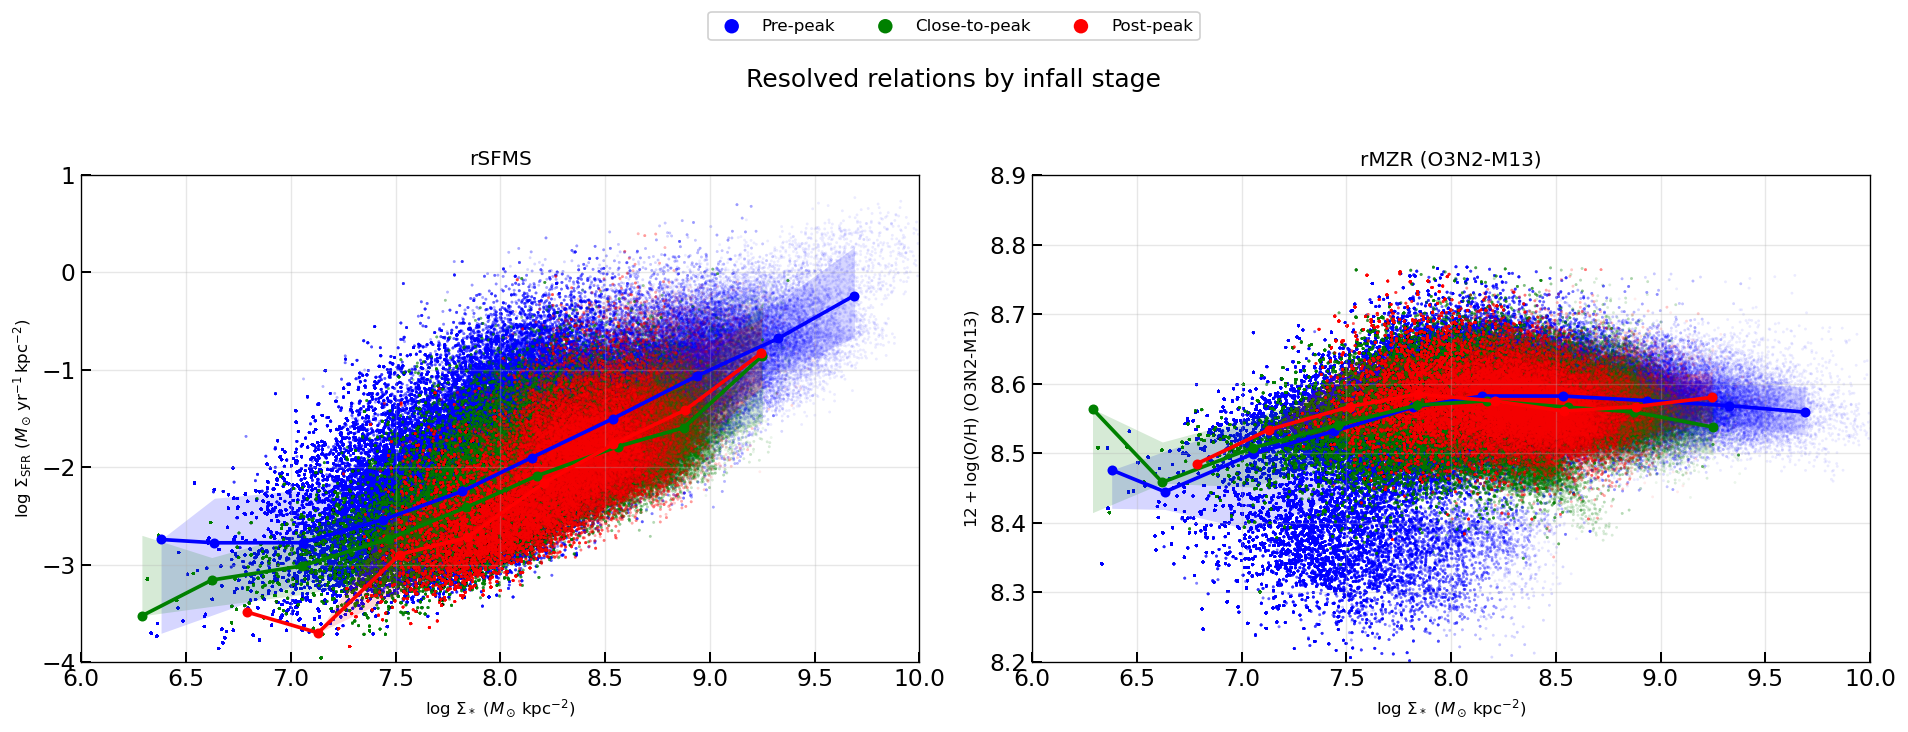

In [10]:
# Standalone side-by-side rSFMS and O3N2-M13 rMZR comparison.
COMBINED_XRANGE = (6.0, 10.0)
COMBINED_RSFMS_YRANGE = (-4.0, 1.0)
COMBINED_RMZR_YRANGE = (8.2, 8.9)
COMBINED_BIN_WIDTH = 0.4
COMBINED_MIN_PIXELS_PER_BIN = 20
COMBINED_EW_MIN = 6.0
COMBINED_EW_HDU = "PROXY_EWHA"
COMBINED_EW_SUFFIX = "_proxy_EW_maps.fits"
COMBINED_EXCLUDED_GALAXIES = {"NGC4383"}
COMBINED_INFALL_COLORS = {1: "blue", 2: "green", 3: "red"}
COMBINED_INFALL_LABELS = {
    1: "Pre-peak", 2: "Close-to-peak", 3: "Post-peak"
}

with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    combined_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
combined_infall_class = add_combined_infall_classes(combined_infall_class)


def combined_binned_percentiles(x, y, bin_edges, min_pixels=20):
    """Return median x/y and the 16th-84th percentile y range per bin."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    x_median, y_median, y16, y84, counts = [], [], [], [], []
    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (x >= left) & (x < right)
        if in_bin.sum() < min_pixels:
            continue
        x_median.append(np.nanmedian(x[in_bin]))
        y_median.append(np.nanmedian(y[in_bin]))
        y16.append(np.nanpercentile(y[in_bin], 16))
        y84.append(np.nanpercentile(y[in_bin], 84))
        counts.append(int(in_bin.sum()))
    return tuple(
        np.asarray(values)
        for values in (x_median, y_median, y16, y84, counts)
    )


def collect_combined_relation(y_hdu, readiness_column, relation_label):
    """Load one relation by infall stage without using another plot cell."""
    ready = (
        PRODUCTS["has_mass_map"]
        & PRODUCTS[readiness_column]
        & PRODUCTS["has_proxy_ew"]
    )
    galaxies = PRODUCTS.index[ready].tolist()
    x_by_stage = {stage: [] for stage in [1, 2, 3]}
    y_by_stage = {stage: [] for stage in [1, 2, 3]}

    print(f"Collecting HII spaxels for {relation_label}...")
    for galaxy in galaxies:
        if galaxy in COMBINED_EXCLUDED_GALAXIES:
            print(f"  {galaxy}: excluded from analysis")
            continue

        stage = combined_infall_class.get(galaxy)
        if stage not in COMBINED_INFALL_COLORS:
            print(f"  {galaxy}: skipped - no infall class in master table")
            continue

        try:
            spatial_path = further_spatial_path(galaxy)
            gas_path = further_gas_path(galaxy)
            ew_path = further_ew_path(galaxy, COMBINED_EW_SUFFIX)
            with fits.open(spatial_path) as hdul:
                log_sigma_m = require_hdu_data(
                    hdul, "LOGMASS_SURFACE_DENSITY", spatial_path
                )
            with fits.open(gas_path) as hdul:
                y_map = require_hdu_data(hdul, y_hdu, gas_path)
            with fits.open(ew_path) as hdul:
                ew_ha = require_hdu_data(hdul, COMBINED_EW_HDU, ew_path)

            log_sigma_m = align_map_to_shape(
                log_sigma_m, y_map.shape, label=f"{galaxy} stellar mass"
            )
            ew_ha = align_map_to_shape(
                ew_ha, y_map.shape, label=f"{galaxy} {COMBINED_EW_HDU}"
            )
        except Exception as exc:
            print(f"  {galaxy}: skipped - {exc}")
            continue

        mask = (
            np.isfinite(log_sigma_m)
            & np.isfinite(y_map)
            & np.isfinite(ew_ha)
            & (ew_ha > COMBINED_EW_MIN)
        )
        n_spaxels = int(mask.sum())
        print(
            f"  {galaxy}: {n_spaxels} HII spaxels, "
            f"stage {stage} ({COMBINED_INFALL_LABELS[stage]})"
        )
        if n_spaxels == 0:
            continue

        x_by_stage[stage].extend(log_sigma_m[mask].ravel())
        y_by_stage[stage].extend(y_map[mask].ravel())

    for stage in [1, 2, 3]:
        x_by_stage[stage] = np.asarray(x_by_stage[stage])
        y_by_stage[stage] = np.asarray(y_by_stage[stage])
    if not any(x_by_stage[stage].size for stage in [1, 2, 3]):
        raise RuntimeError(f"No valid HII spaxels found for {relation_label}.")
    return x_by_stage, y_by_stage


combined_logSigmaM_rsfms, combined_logSigmaSFR = collect_combined_relation(
    "LOGSFR_SURFACE_DENSITY_HII", "has_sfr_map", "rSFMS"
)
combined_logSigmaM_rmzr, combined_oh_m13 = collect_combined_relation(
    "O_H_O3N2_M13_HII", "has_o3n2_m13", "O3N2-M13 rMZR"
)

fig, (ax_sfms, ax_rmzr) = plt.subplots(
    1, 2, figsize=(16, 6), sharex=True
)

combined_mass_bins = np.arange(
    COMBINED_XRANGE[0],
    COMBINED_XRANGE[1] + COMBINED_BIN_WIDTH,
    COMBINED_BIN_WIDTH,
)


def plot_infall_stage_panel(ax, x_by_stage, y_by_stage, *, ylabel, ylim, title):
    """Plot faint spaxels plus three stage median trends on one axis."""
    scatter_handles = []
    for stage in [1, 2, 3]:
        x = x_by_stage[stage]
        y = y_by_stage[stage]
        if x.size == 0:
            continue

        color = COMBINED_INFALL_COLORS[stage]
        label = COMBINED_INFALL_LABELS[stage]
        scatter = ax.scatter(
            x, y, s=3, alpha=0.08, color=color, edgecolors="none",
            rasterized=True, label=label,
        )
        scatter_handles.append(scatter)

        x_med, y_med, y16, y84, counts = combined_binned_percentiles(
            x, y, combined_mass_bins,
            min_pixels=COMBINED_MIN_PIXELS_PER_BIN,
        )
        if x_med.size:
            ax.fill_between(
                x_med, y16, y84, color=color, alpha=0.16, linewidth=0
            )
            ax.plot(
                x_med, y_med, color=color, marker="o",
                markersize=5, linewidth=2.2,
            )

    ax.set(
        xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
        ylabel=ylabel,
        xlim=COMBINED_XRANGE,
        ylim=ylim,
        title=title,
    )
    ax.grid(True, alpha=0.3)
    return scatter_handles


legend_handles = plot_infall_stage_panel(
    ax_sfms,
    combined_logSigmaM_rsfms,
    combined_logSigmaSFR,
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylim=COMBINED_RSFMS_YRANGE,
    title="rSFMS",
)

plot_infall_stage_panel(
    ax_rmzr,
    combined_logSigmaM_rmzr,
    combined_oh_m13,
    ylabel=r"$12 + \log(\mathrm{O/H})$ (O3N2-M13)",
    ylim=COMBINED_RMZR_YRANGE,
    title="rMZR (O3N2-M13)",
)

legend = fig.legend(
    handles=legend_handles,
    labels=[COMBINED_INFALL_LABELS[stage] for stage in [1, 2, 3]],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)

fig.suptitle("Resolved relations by infall stage", y=0.93, fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.90))
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_rMZR_O3N2_M13_infall_EW.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_rMZR_O3N2_M13_infall_EW.pdf", bbox_inches="tight")
plt.show()